In [1]:
import numpy as np

# Creation of a 5x5 matrix where border elements are 1 and interior is 0
matrix = np.ones((5, 5))
matrix[1:4, 1:4] = 0
print("5x5 Border Matrix:")
print(matrix)

5x5 Border Matrix:
[[1. 1. 1. 1. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 0. 0. 0. 1.]
 [1. 1. 1. 1. 1.]]


In [2]:
# Normalization of a random array
np.random.seed(42)
random_data = np.random.randn(100, 3)

# Normalizion of each column to have mean=0 and std=1
normalized = (random_data - random_data.mean(axis=0)) / random_data.std(axis=0)

print("Original data stats:")
print(f"Mean: {random_data.mean(axis=0).round(3)}")
print(f"Std:  {random_data.std(axis=0).round(3)}")

print("\nNormalized data stats:")
print(f"Mean: {normalized.mean(axis=0).round(3)}")
print(f"Std:  {normalized.std(axis=0).round(3)}")

Original data stats:
Mean: [ 0.092 -0.183  0.075]
Std:  [0.821 0.974 1.107]

Normalized data stats:
Mean: [-0.  0. -0.]
Std:  [1. 1. 1.]


In [3]:
# Linear Regression using Normal Equation
# Formula: theta = (X^T X)^(-1) X^T y

np.random.seed(42)
X = np.random.randn(50, 3)
true_theta = np.array([2.5, -1.2, 3.7])
y = X @ true_theta + np.random.randn(50) * 0.1

# Calculate teta using normal equation
theta_hat = np.linalg.inv(X.T @ X) @ X.T @ y

print("True theta:      ", true_theta)
print("Estimated theta: ", theta_hat.round(3))
print("\nDifference:      ", (true_theta - theta_hat).round(3))

True theta:       [ 2.5 -1.2  3.7]
Estimated theta:  [ 2.512 -1.215  3.699]

Difference:       [-0.012  0.015  0.001]


In [4]:
import pandas as pd
import numpy as np

# Creating sample dataset
np.random.seed(42)
n_students = 200

data = {
    'student_id': range(1000, 1000 + n_students),
    'major': np.random.choice(['Computer Ssience', 'Engineering', 'Business Admin', 'Economie'], n_students),
    'year': np.random.choice([1, 2, 3, 4], n_students),
    'exam_score': np.random.normal(75, 10, n_students).clip(0, 100),
    'assignments_completed': np.random.randint(0, 11, n_students),
    'hours_studied': np.random.normal(15, 5, n_students).clip(1, 40)
}

df = pd.DataFrame(data)

# Introducing some NaN values
df.loc[np.random.choice(n_students, 10), 'exam_score'] = np.nan
df.loc[np.random.choice(n_students, 5), 'hours_studied'] = np.nan

print("Dataset created successfully!")
print(f"Shape: {df.shape}")
print(df.head())

Dataset created successfully!
Shape: (200, 6)
   student_id             major  year  exam_score  assignments_completed  \
0        1000    Business Admin     3   68.199753                     10   
1        1001          Economie     4   77.322537                      9   
2        1002  Computer Ssience     3   77.930725                      9   
3        1003    Business Admin     1   67.856486                      2   
4        1004    Business Admin     4   93.657745                      6   

   hours_studied  
0            NaN  
1      12.204873  
2       7.829556  
3      14.042336  
4      15.287370  


In [5]:
# Data Cleaning and Exploration

# Display basic information
print("DATASET INFO: ")
print(df.info())

print("\n MISSING VALUES: ")
print(df.isnull().sum())

# Fill missing exam_score with mean score for each major
df['exam_score'] = df.groupby('major')['exam_score'].transform(
    lambda x: x.fillna(x.mean())
)

# Fill missing hours_studied with median for each year
df['hours_studied'] = df.groupby('year')['hours_studied'].transform(
    lambda x: x.fillna(x.median())
)

print("\n MISSING VALUES AFTER CLEANING: ")
print(df.isnull().sum())
print("\nAll missing values handled! ")

DATASET INFO: 
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             200 non-null    int64  
 1   major                  200 non-null    str    
 2   year                   200 non-null    int64  
 3   exam_score             190 non-null    float64
 4   assignments_completed  200 non-null    int32  
 5   hours_studied          195 non-null    float64
dtypes: float64(2), int32(1), int64(2), str(1)
memory usage: 8.7 KB
None

 MISSING VALUES: 
student_id                0
major                     0
year                      0
exam_score               10
assignments_completed     0
hours_studied             5
dtype: int64

 MISSING VALUES AFTER CLEANING: 
student_id               0
major                    0
year                     0
exam_score               0
assignments_completed    0
hours_studied            0
dtype: 

In [6]:
# Data Analysis

# Average exam score by major
print("AVERAGE EXAM SCORE BY MAJOR: ")
avg_by_major = df.groupby('major')['exam_score'].mean().round(2)
print(avg_by_major)

# Major with highest average
best_major = avg_by_major.idxmax()
print(f"\nBest performing major: {best_major} ({avg_by_major[best_major]:.2f})")

# Correlation between hours studied and exam score
correlation = df['hours_studied'].corr(df['exam_score'])
print(f"\nCorrelation between hours studied and exam score: {correlation:.3f}")

# Performance categories
def categorize(score):
    if score > 90:
        return 'Excellent'
    elif score >= 80:
        return 'Good'
    elif score >= 70:
        return 'Average'
    else:
        return 'Needs Improvement'

df['performance'] = df['exam_score'].apply(categorize)

print("\n PERFORMANCE CATEGORIES: ")
print(df['performance'].value_counts())

AVERAGE EXAM SCORE BY MAJOR: 
major
Business Admin      75.41
Computer Ssience    76.43
Economie            75.50
Engineering         74.68
Name: exam_score, dtype: float64

Best performing major: Computer Ssience (76.43)

Correlation between hours studied and exam score: -0.056

 PERFORMANCE CATEGORIES: 
performance
Average              77
Needs Improvement    59
Good                 52
Excellent            12
Name: count, dtype: int64


In [7]:
# Advanced data Analysis

# For each major and year combination we calculate stats
print("STATS BY MAJOR AND YEAR: ")
grouped = df.groupby(['major', 'year']).agg(
    num_students=('student_id', 'count'),
    avg_exam_score=('exam_score', 'mean'),
    avg_hours_studied=('hours_studied', 'mean')
).round(2)
print(grouped)

# Top 5 students by exam score
print("\n TOP 5 STUDENTS: ")
top5 = df.nlargest(5, 'exam_score')[['student_id', 'major', 'year', 'exam_score']]
print(top5)

# Pivot table
print("\n PIVOT TABLE: AVG EXAM SCORE BY MAJOR AND YEAR: ")
pivot = df.pivot_table(
    values='exam_score',
    index='major',
    columns='year',
    aggfunc='mean'
).round(2)
print(pivot)

STATS BY MAJOR AND YEAR: 
                       num_students  avg_exam_score  avg_hours_studied
major            year                                                 
Business Admin   1               13           77.83              13.49
                 2               12           73.28              14.62
                 3               17           73.13              14.20
                 4               12           78.13              15.55
Computer Ssience 1               12           77.10              13.04
                 2                7           76.16              14.00
                 3                9           72.35              15.04
                 4               18           78.12              16.28
Economie         1               13           76.57              12.68
                 2               12           74.90              13.43
                 3               14           80.18              14.49
                 4               15           70.70

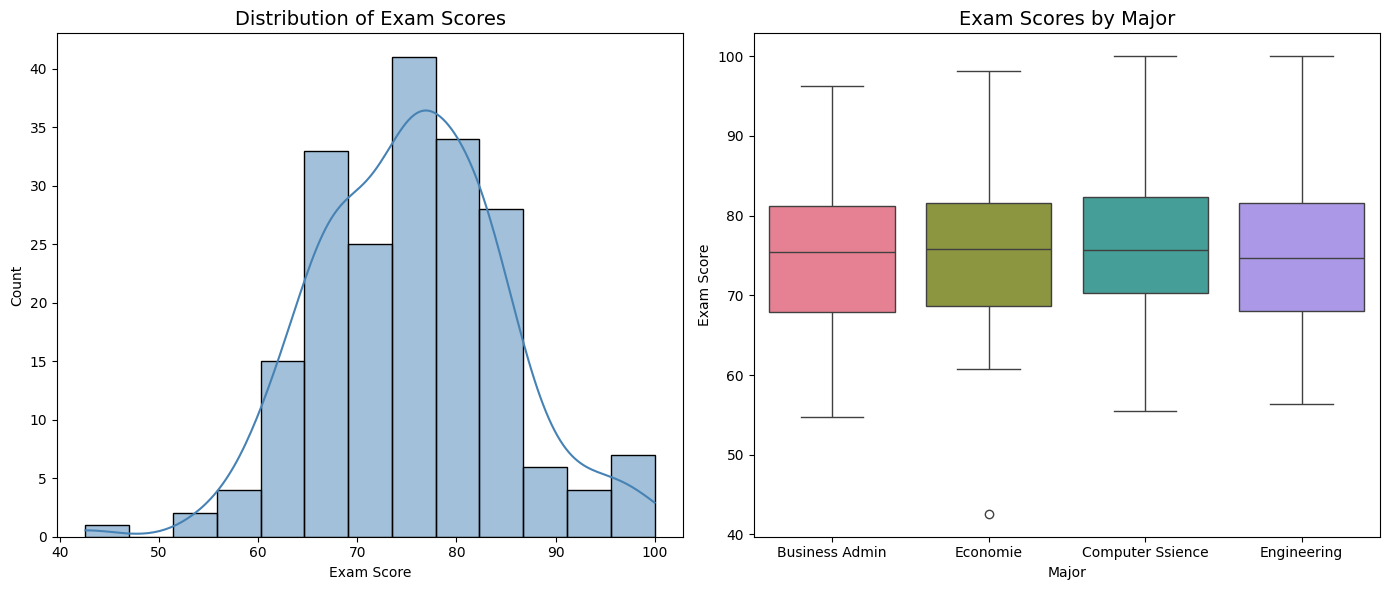

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Histogram with KDE overlay
sns.histplot(data=df, x='exam_score', kde=True, ax=ax1, color='steelblue')
ax1.set_title('Distribution of Exam Scores', fontsize=14)
ax1.set_xlabel('Exam Score')
ax1.set_ylabel('Count')

# Box plot by major (updated for newer seaborn)
sns.boxplot(data=df, x='major', y='exam_score', ax=ax2, 
            hue='major', legend=False, palette='husl')
ax2.set_title('Exam Scores by Major', fontsize=14)
ax2.set_xlabel('Major')
ax2.set_ylabel('Exam Score')

plt.tight_layout()
plt.show()

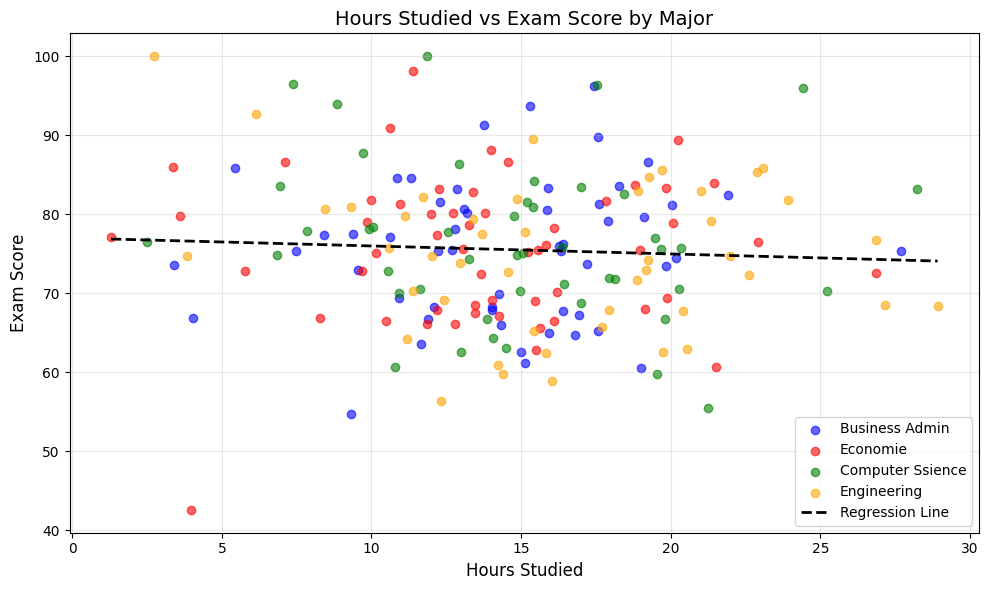

In [10]:
# Relationship Visualization
fig, ax = plt.subplots(figsize=(10, 6))

# Scatter plot colored by major
majors = df['major'].unique()
colors = ['blue', 'red', 'green', 'orange']

for major, color in zip(majors, colors):
    mask = df['major'] == major
    ax.scatter(df[mask]['hours_studied'], 
               df[mask]['exam_score'],
               label=major, 
               color=color, 
               alpha=0.6)

# With regression line
z = np.polyfit(df['hours_studied'], df['exam_score'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['hours_studied'].min(), 
                     df['hours_studied'].max(), 100)
ax.plot(x_line, p(x_line), "k--", linewidth=2, label='Regression Line')

ax.set_xlabel('Hours Studied', fontsize=12)
ax.set_ylabel('Exam Score', fontsize=12)
ax.set_title('Hours Studied vs Exam Score by Major', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

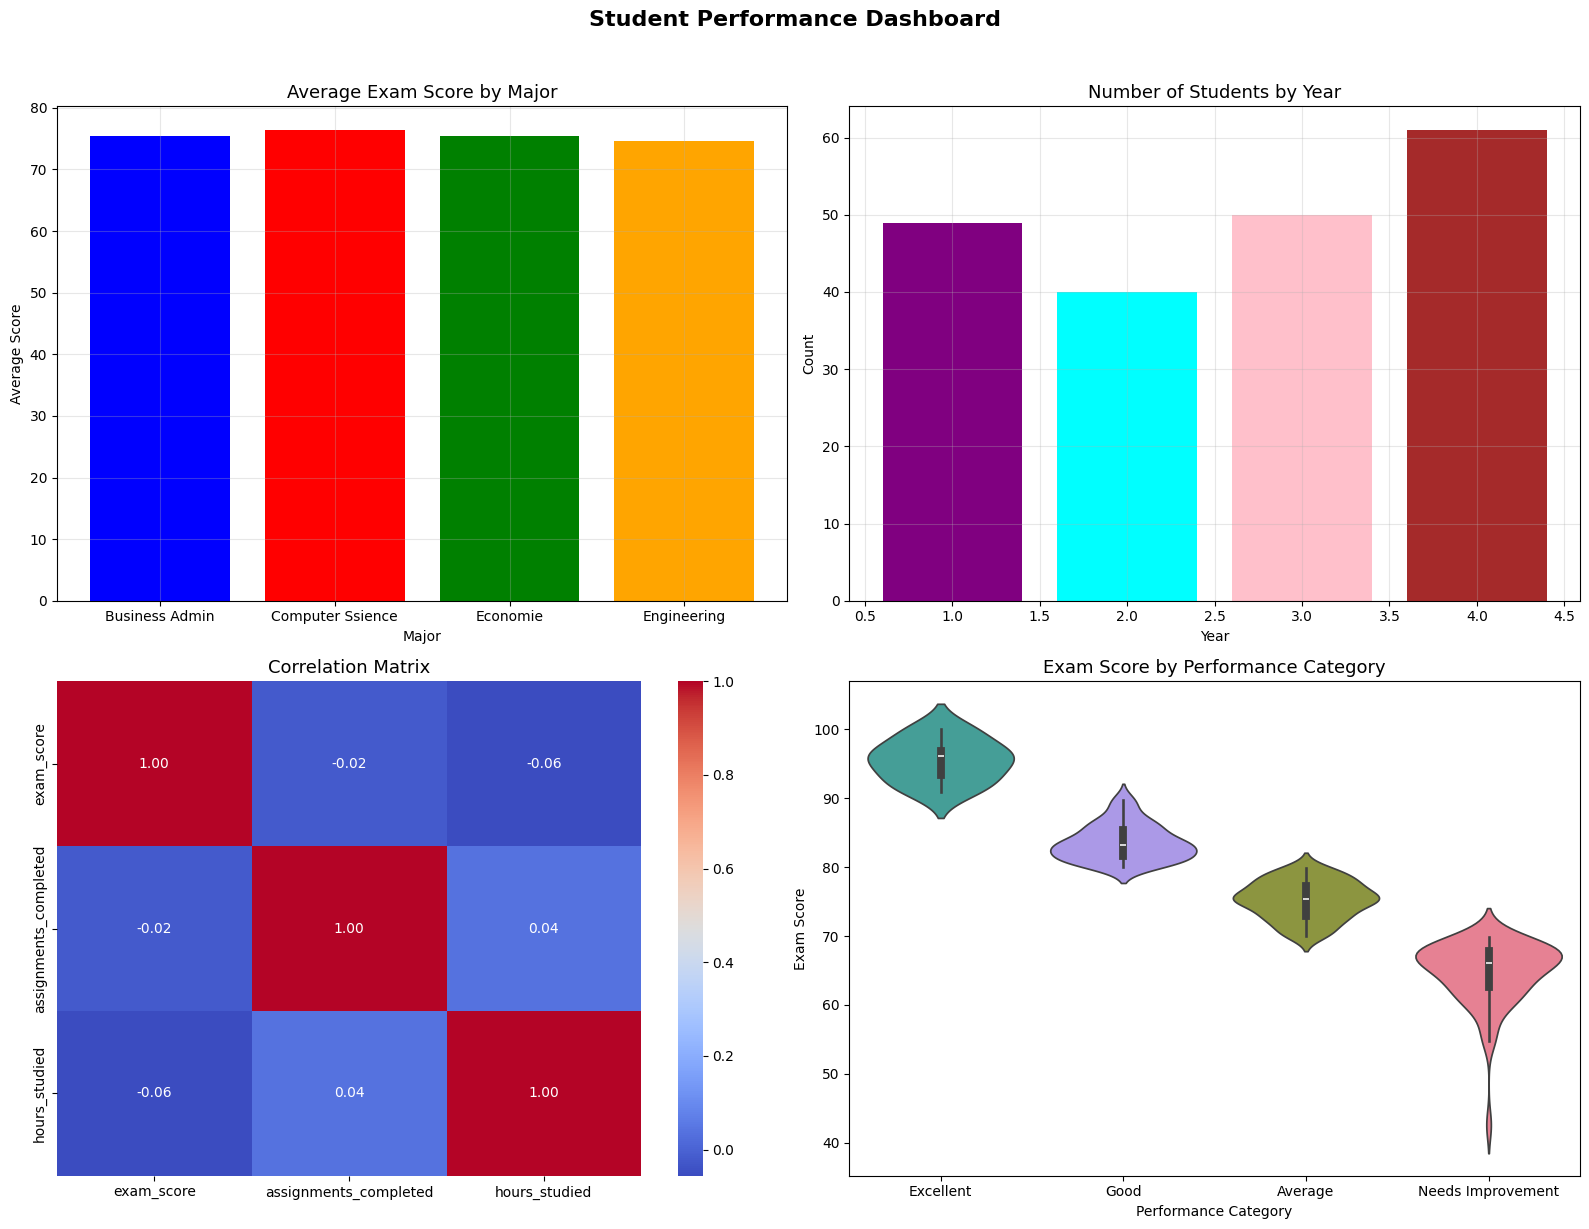

In [11]:
# Advanced Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Bar chart: Average exam score by major
avg_scores = df.groupby('major')['exam_score'].mean()
axes[0, 0].bar(avg_scores.index, avg_scores.values, 
                color=['blue', 'red', 'green', 'orange'])
axes[0, 0].set_title('Average Exam Score by Major', fontsize=13)
axes[0, 0].set_xlabel('Major')
axes[0, 0].set_ylabel('Average Score')
axes[0, 0].grid(True, alpha=0.3)

# Count plot: Number of students by year
year_counts = df['year'].value_counts().sort_index()
axes[0, 1].bar(year_counts.index, year_counts.values,
                color=['purple', 'cyan', 'pink', 'brown'])
axes[0, 1].set_title('Number of Students by Year', fontsize=13)
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Count')
axes[0, 1].grid(True, alpha=0.3)

# Correlation matrix
numerical_cols = df[['exam_score', 'assignments_completed', 'hours_studied']]
correlation = numerical_cols.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm', 
            ax=axes[1, 0], fmt='.2f')
axes[1, 0].set_title('Correlation Matrix', fontsize=13)

# Violin plot: Exam score by performance category
order = ['Excellent', 'Good', 'Average', 'Needs Improvement']
sns.violinplot(data=df, x='performance', y='exam_score',
               order=order, ax=axes[1, 1],
               hue='performance', legend=False, palette='husl')
axes[1, 1].set_title('Exam Score by Performance Category', fontsize=13)
axes[1, 1].set_xlabel('Performance Category')
axes[1, 1].set_ylabel('Exam Score')

plt.suptitle('Student Performance Dashboard', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
n_customers = 500

# Generating customer data
ages = np.random.randint(18, 70, n_customers)
income = np.random.normal(50000, 20000, n_customers).clip(15000, 150000)
purchase_freq = np.random.poisson(5, n_customers)
avg_purchase_value = np.random.normal(100, 30, n_customers).clip(10, 500)

# Create DataFrame
customers = pd.DataFrame({
    'age': ages,
    'income': income,
    'purchase_frequency': purchase_freq,
    'avg_purchase_value': avg_purchase_value
})

# Calculate Customer Lifetime Value (CLV)
max_frequency = customers['purchase_frequency'].max()
customers['churn_risk'] = 1 - (customers['purchase_frequency'] / max_frequency)
customers['CLV'] = (customers['purchase_frequency'] * 
                    customers['avg_purchase_value'] * 
                    (1 + customers['churn_risk']))

print("CUSTOMER DATA: ")
print(customers.head())
print(f"\nShape: {customers.shape}")
print(f"\nCLV Statistics:")
print(customers['CLV'].describe().round(2))

CUSTOMER DATA: 
   age        income  purchase_frequency  avg_purchase_value  churn_risk  \
0   56  92443.123940                   7           94.527456    0.416667   
1   69  70649.305211                   2          100.932279    0.833333   
2   46  19612.600681                   3           79.699876    0.750000   
3   32  40315.318543                   2          130.137787    0.833333   
4   60  75338.222984                   8          102.904845    0.333333   

           CLV  
0   937.397271  
1   370.085023  
2   418.424348  
3   477.171887  
4  1097.651683  

Shape: (500, 6)

CLV Statistics:
count     500.00
mean      743.76
std       349.91
min         0.00
25%       481.94
50%       712.26
75%       969.63
max      1645.71
Name: CLV, dtype: float64


In [13]:
# Create age groups
customers['age_group'] = pd.cut(
    customers['age'],
    bins=[18, 25, 35, 50, 70],
    labels=['18-25', '26-35', '36-50', '51-70']
)

# Calculate stats for each group
print("STATS BY AGE GROUP: ")
age_stats = customers.groupby('age_group', observed=True).agg(
    num_customers=('age', 'count'),
    avg_income=('income', 'mean'),
    avg_CLV=('CLV', 'mean'),
    total_CLV=('CLV', 'sum')
).round(2)
print(age_stats)

# Top 10% customers by CLV
print("\n TOP 10% CUSTOMERS BY CLV: ")
threshold = customers['CLV'].quantile(0.90)
top_customers = customers[customers['CLV'] >= threshold]
print(f"CLV Threshold for top 10%: {threshold:.2f}")
print(f"Number of top customers: {len(top_customers)}")
print(top_customers[['age', 'age_group', 'income', 
                      'purchase_frequency', 'CLV']].head(10))

STATS BY AGE GROUP: 
           num_customers  avg_income  avg_CLV  total_CLV
age_group                                               
18-25                 69    51805.88   704.49   48609.99
26-35                 73    48747.15   747.74   54584.92
36-50                160    48516.90   732.80  117247.46
51-70                186    50713.16   762.69  141860.99

 TOP 10% CUSTOMERS BY CLV: 
CLV Threshold for top 10%: 1222.94
Number of top customers: 50
    age age_group        income  purchase_frequency          CLV
6    38     36-50  58876.388563                  10  1287.201143
9    40     36-50  48809.492879                  10  1286.000108
19   41     36-50  21282.756976                   8  1276.279663
24   38     36-50  53981.193911                   8  1283.421714
57   64     51-70  45956.146951                   7  1343.416638
60   25     18-25  66508.326980                   7  1408.591795
76   61     51-70  62482.396341                   7  1267.760075
79   53     51-70  32054.

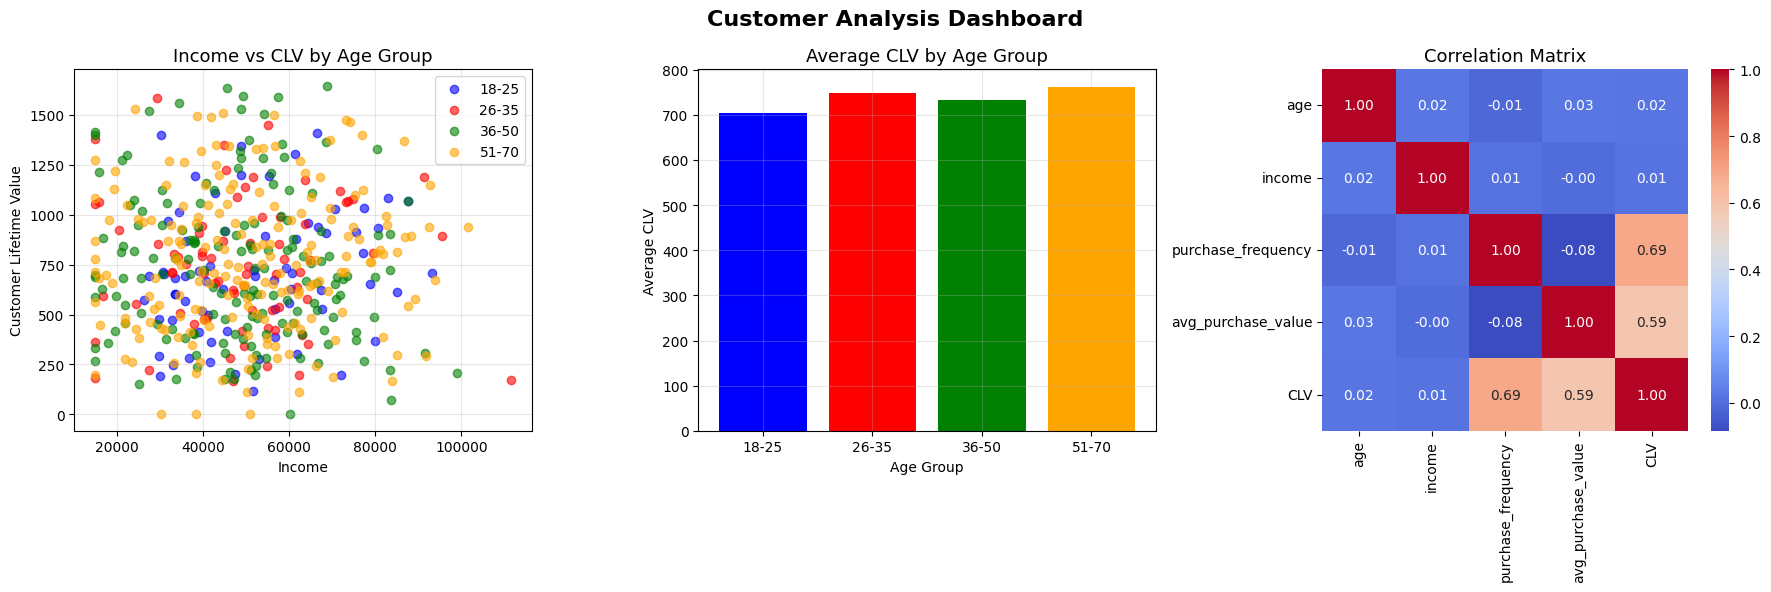

In [15]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Scatter plot: Income vs CLV colored by age group
age_groups = ['18-25', '26-35', '36-50', '51-70']
colors = ['blue', 'red', 'green', 'orange']

for age_group, color in zip(age_groups, colors):
    mask = customers['age_group'] == age_group
    axes[0].scatter(customers[mask]['income'],
                   customers[mask]['CLV'],
                   label=age_group,
                   color=color,
                   alpha=0.6)

axes[0].set_title('Income vs CLV by Age Group', fontsize=13)
axes[0].set_xlabel('Income')
axes[0].set_ylabel('Customer Lifetime Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Bar chart: Average CLV by age group
avg_clv = customers.groupby('age_group', observed=True)['CLV'].mean()
axes[1].bar(avg_clv.index.astype(str), avg_clv.values,
            color=['blue', 'red', 'green', 'orange'])
axes[1].set_title('Average CLV by Age Group', fontsize=13)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Average CLV')
axes[1].grid(True, alpha=0.3)

# Correlation heatmap
numerical = customers[['age', 'income', 'purchase_frequency',
                        'avg_purchase_value', 'CLV']]
correlation = numerical.corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm',
            ax=axes[2], fmt='.2f')
axes[2].set_title('Correlation Matrix', fontsize=13)

plt.suptitle('Customer Analysis Dashboard',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [17]:
# Analysis Summary
summary = f"""
=== CUSTOMER ANALYSIS SUMMARY ===

  The dataset contains information about 500 customers. On average, each customer has a Customer Lifetime Value (CLV) of $743.76, 
  which shows how much value they bring to the business over time. 
  The customer with the highest CLV brings in $1645.71, while the lowest CLV is $0.00, meaning some customers have not generated any value at all.
  The age group that brings the most value to the business is people aged 51–70 years, meaning they have the highest CLV on average. 
  Interestingly, this same age group also has the largest number of customers, so most of the business’s customers are in this older adult category.
  The top 10% of customers are those whose CLV is above $1222.94, and there are 50 such high-value customers. 
  These top customers are especially important because they generate the most revenue, and on average they earn about $47,864.94, which suggests they also tend to have relatively high incomes.
  Therefore, the business should focus its marketing efforts on the age group that generates the highest CLV, since they bring in the most value. 
  It should also target customers who buy frequently because they contribute more over time. 
  Also, the company should keep the top 10% of customers happy by using loyalty programs so they continue staying with the business.
"""

print(summary)


=== CUSTOMER ANALYSIS SUMMARY ===

  The dataset contains information about 500 customers. On average, each customer has a Customer Lifetime Value (CLV) of $743.76, 
  which shows how much value they bring to the business over time. 
  The customer with the highest CLV brings in $1645.71, while the lowest CLV is $0.00, meaning some customers have not generated any value at all.
  The age group that brings the most value to the business is people aged 51–70 years, meaning they have the highest CLV on average. 
  Interestingly, this same age group also has the largest number of customers, so most of the business’s customers are in this older adult category.
  The top 10% of customers are those whose CLV is above $1222.94, and there are 50 such high-value customers. 
  These top customers are especially important because they generate the most revenue, and on average they earn about $47,864.94, which suggests they also tend to have relatively high incomes.
  Therefore, the business shoul